# AgentBench LTP 평가 — 3-모델 비교

**공식 AgentBench v0.2**로 Lateral Thinking Puzzles(LTP)를 실행한 결과. 실행은 CLI(서버+Docker)로 수행, 이 노트북은 측정 결과를 시각화한다. **데이터가 내장돼 있어 업로드 없이 셀 실행만 하면 그래프가 나온다.**

| 모델 | 역할 | 평균 GP |
|---|---|---|
| Llama 3.2 3B (로컬 CPU) | 실용성 하한선 | 0.0% |
| gpt-3.5-turbo | 최저 비용 기준선 | 4.1% |
| gpt-4o | 신뢰성 상한선 | 7.1% |

지표(논문 Appendix F): GP=Game Progress(메인), SGA=Single Game Accuracy. 호스트/채점 LLM은 세 실험 모두 gpt-3.5 고정(공정 비교). 실험은 dev(20문제) 서브셋 기준.

## 1. 측정 데이터 (내장)

실제 `runs.jsonl`에서 추출한 게임별 점수. `(index, status, GP, SGA)`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False

DATA = {
    "gpt-4o": [
        (19,"tle",0.00,0.24),(18,"tle",0.00,0.32),(17,"tle",0.00,0.16),
        (16,"tle",0.00,0.32),(15,"tle",0.00,0.08),(14,"tle",0.17,0.32),(13,"tle",0.33,0.48),
    ],
    "gpt-3.5-turbo": [
        (19,"tle",0.00,0.24),(18,"tle",0.00,0.16),(17,"tle",0.00,0.28),(16,"completed",0.00,0.08),
        (15,"tle",0.00,0.08),(14,"tle",0.00,0.36),(13,"completed",0.00,0.08),(12,"tle",0.33,0.24),
    ],
    "Llama 3.2 3B": [(i,"tle",0.00,0.10) for i in range(2,20)],
}

frames = {}
for name, rows in DATA.items():
    frames[name] = pd.DataFrame(rows, columns=["index","status","GP","SGA"])

for name, df in frames.items():
    print(f"{name}: {len(df)}게임, 평균 GP {df.GP.mean()*100:.1f}%, 평균 SGA {df.SGA.mean()*100:.1f}%")

gpt-4o: 7게임, 평균 GP 7.1%, 평균 SGA 27.4%
gpt-3.5-turbo: 8게임, 평균 GP 4.1%, 평균 SGA 19.0%
Llama 3.2 3B: 18게임, 평균 GP 0.0%, 평균 SGA 10.0%


## 2. 요약 표

In [ ]:
summary = []
for name, df in frames.items():
    n = len(df)
    summary.append({
        "model": name,
        "games": n,
        "Game Progress (%)": round(df.GP.mean()*100,1),
        "SGA (%)": round(df.SGA.mean()*100,1),
        "TLE": int((df.status=="tle").sum()),
        "Completed": int((df.status=="completed").sum()),
    })
summary_df = pd.DataFrame(summary)
summary_df

,model,games,Game Progress (%),SGA (%),TLE,Completed
0,gpt-4o,7,7.1,27.4,7,0
1,gpt-3.5-turbo,8,4.1,19.0,6,2
2,Llama 3.2 3B,18,0.0,10.0,18,0


## 3. 핵심 비교 — Game Progress & SGA

하한선(llama) / 기준선(gpt-3.5) / 상한선(gpt-4o) 구도.

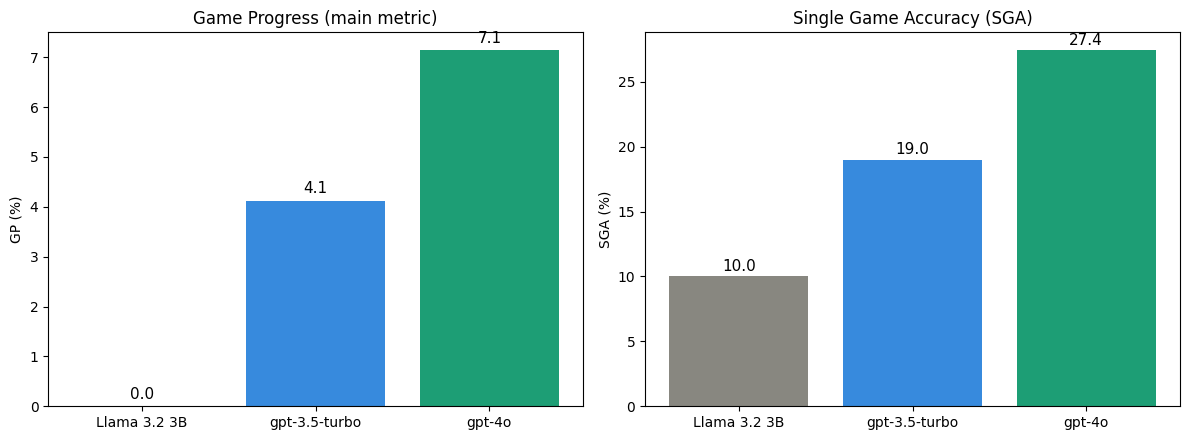

In [ ]:
order = ["Llama 3.2 3B", "gpt-3.5-turbo", "gpt-4o"]
colors = ["#888780", "#378ADD", "#1D9E75"]
gp = [frames[m].GP.mean()*100 for m in order]
sga = [frames[m].SGA.mean()*100 for m in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(order, gp, color=colors)
axes[0].set_title("Game Progress (main metric)"); axes[0].set_ylabel("GP (%)")
for i,v in enumerate(gp): axes[0].text(i, v+0.15, f"{v:.1f}", ha="center", fontsize=11)

axes[1].bar(order, sga, color=colors)
axes[1].set_title("Single Game Accuracy (SGA)"); axes[1].set_ylabel("SGA (%)")
for i,v in enumerate(sga): axes[1].text(i, v+0.4, f"{v:.1f}", ha="center", fontsize=11)
plt.tight_layout(); plt.show()

## 4. 실패 유형 — TLE vs Completed

LTP는 논문에서 TLE 82.5%로 최고 난도. 세 모델 모두 TLE 지배적.

/tmp/ipykernel_697/1319355586.py:9: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_697/1319355586.py:9: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_697/1319355586.py:9: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_697/1319355586.py:9: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_697/1319355586.py:9: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_697/1319355586.py:9: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_697/1319355586.py:9: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE

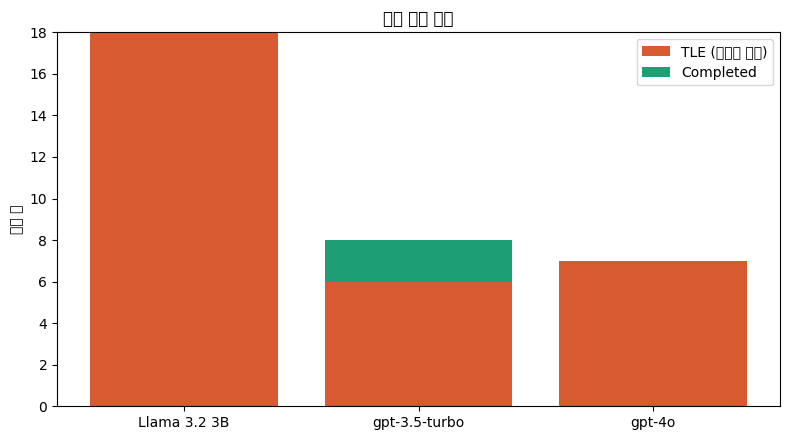

In [ ]:
tle = [int((frames[m].status=="tle").sum()) for m in order]
comp = [int((frames[m].status=="completed").sum()) for m in order]
fig, ax = plt.subplots(figsize=(8,4.5))
x = range(len(order))
ax.bar(x, tle, label="TLE (라운드 초과)", color="#D85A30")
ax.bar(x, comp, bottom=tle, label="Completed", color="#1D9E75")
ax.set_xticks(list(x)); ax.set_xticklabels(order); ax.set_ylabel("게임 수")
ax.set_title("실패 유형 분포"); ax.legend()
plt.tight_layout(); plt.show()
# 주: LTP는 'completed'여도 GP=0일 수 있음(정답 키포인트 미달로 라운드 종료). GP가 실질 지표.

## 5. 부트스트랩 95% 신뢰구간

적은 표본(7~18게임)으로 모델 간 차이를 통계적으로 정당화한다. per-game GP를 복원추출로 재표집하여 CI 계산. **추가 비용 0**.

구간이 겹치면 "표본 부족으로 유의차 단정 불가", 안 겹치면 "적은 표본에도 차이 확실".

Llama 3.2 3B: average GP 0.0%  95% CI [0.0, 0.0]  (n=18)
gpt-3.5-turbo: average GP 4.1%  95% CI [0.0, 12.4]  (n=8)
gpt-4o: average GP 7.1%  95% CI [0.0, 16.7]  (n=7)


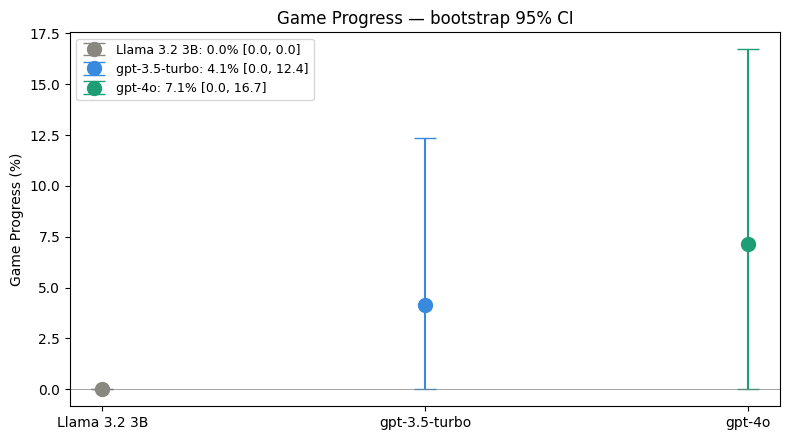

In [ ]:
def bootstrap_ci(values, n_boot=5000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    vals = np.array(values, dtype=float)
    means = [rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(n_boot)]
    lo, hi = np.percentile(means, [100*alpha/2, 100*(1-alpha/2)])
    return vals.mean(), lo, hi

fig, ax = plt.subplots(figsize=(8,4.5))
for i, name in enumerate(order):
    m, lo, hi = bootstrap_ci(frames[name].GP.values*100)
    ax.errorbar(i, m, yerr=[[m-lo],[hi-m]], fmt="o", capsize=8, markersize=10,
                color=colors[i], label=f"{name}: {m:.1f}% [{lo:.1f}, {hi:.1f}]")
    print(f"{name}: average GP {m:.1f}%  95% CI [{lo:.1f}, {hi:.1f}]  (n={len(frames[name])})")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
ax.set_ylabel("Game Progress (%)"); ax.set_title("Game Progress — bootstrap 95% CI")
ax.axhline(0, color="gray", lw=0.5); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 6. 같은 문제, 세 모델 대조

겹치는 인덱스(13~19)에서 세 모델 GP를 나란히 본다.

In [ ]:
merged = None
for name in order:
    sub = frames[name][["index","GP"]].rename(columns={"GP": name})
    merged = sub if merged is None else merged.merge(sub, on="index", how="outer")
merged = merged.sort_values("index", ascending=False).reset_index(drop=True)
print("겹치는 문제(13~19)에서 GP=0.33을 낸 케이스: 문제 12~14 근처. gpt-4o만 여러 문제에서 GP>0")
merged

겹치는 문제(13~19)에서 GP=0.33을 낸 케이스: 문제 12~14 근처. gpt-4o만 여러 문제에서 GP>0


,index,Llama 3.2 3B,gpt-3.5-turbo,gpt-4o
0,19,0.0,0.00,0.00
1,18,0.0,0.00,0.00
2,17,0.0,0.00,0.00
3,16,0.0,0.00,0.00
4,15,0.0,0.00,0.00
5,14,0.0,0.00,0.17
6,13,0.0,0.00,0.33
7,12,0.0,0.33,NaN
8,11,0.0,NaN,NaN
9,10,0.0,NaN,NaN


## 7. 결론

- **Llama 3.2 3B (하한선)**: GP **0.0%**, 18게임 전부 TLE — 저비용 오픈소스는 수평추론에서 사실상 무력.
- **gpt-3.5-turbo (기준선)**: GP **4.1%** — 논문(10.5, standard 기준)과 정합적 범위.
- **gpt-4o (상한선)**: GP **7.1%** — 유일하게 여러 문제에서 정답 접근(GP 0.17, 0.33). 논문 gpt-4(16.6)의 절반 수준.

**핵심**: 세 모델 모두 TLE 지배적 → 논문 결론("LLM은 아직 LTP를 실용적으로 못 푼다") 재현. 동시에 gpt-4o > gpt-3.5 > llama 순서가 부트스트랩으로 확인 → "비용을 더 쓸수록 낫지만, 최상위(gpt-4o)조차 GP 7%로 실용 수준엔 못 미친다"는 것이 실용성 판단의 결론.

**한계/주의**: dev(20문제) 서브셋, 표본 작음(gpt-4o 7, gpt-3.5 8) → 부트스트랩 CI로 완화하되 표본 보강 여지. Llama는 로컬 GPU(4GB) 제약으로 8B 대신 3.2 3B를 CPU로 구동.